# Глубокое обучение


# Тема 7. Диффузионные модели 🔥 Одномерные распределения

Наряду с GAN, __модели диффузии__ (diffusion models) или __диффузионные модели__ являются одним из наиболее влиятельных и действенных методов генеративного моделирования для генерации изображений, которые были предложены за последнее десятилетие. Во многих тестах диффузионные модели теперь превосходят наиболее совершенные GAN и быстро становятся предпочтительным выбором для практиков генеративного моделирования, особенно для визуализации (например, DALL.E 2 от компании OpenAI и ImageGen от компании Google для генерации изображений по тексту). В последнее время произошел взрывной рост числа диффузионных моделей, применяемых для решения широкого круга задач, что напоминает распространение GAN, которое имело место в период 2017–2020 годов. 

Многие из основных идей, лежащих в основе диффузионных моделей, имеют сходство с более ранними типами генеративных моделей, которые мы уже рассматривали (например, автоэнкодеры с шумоподавлением, энергетические модели). Действительно, название «диффузия» вдохновлено хорошо изученным свойством термодинамической диффузии – была установлена важная связь между этой чисто физической областью и глубоким обучением.

Рассмотрим класс генеративных моделей, основанных на диффузионных процессах, т. е. специфических стохастических процессах, динамика которых напоминает уравнение диффузии.

### Процессы прямой диффузии

Целью генеративной диффузионной модели является формирование выборок с распределением $\mu$, для которого имеется обучающий набор данных $\boldsymbol{x}_1,...,\boldsymbol{x}_n \sim \mu$. Для этого устанавливается связь между известным распределением (стандартным нормальным распределением) и $\mu$. Это похоже на вариационный автокодировщик (VAE), в конструкции которого предполагалось, что выборки из латентного (скрытого) пространства следуют гауссовскому распределению и отображаются в исходное пространство данных декодером.

Дискретный во времени прямой диффузионный процесс (forward diffusion process), начинающийся в точке данных $\boldsymbol{x}^{\left(0\right)} \in \mathbb{R}^{d}$ с некоторым неизвестным распределением $\mu$, определяется как

$$ \boldsymbol{x}^{\left(i\right)}=\sqrt{1-\beta_{i}}\boldsymbol{x}^{\left(i-1\right)}+\sqrt{\beta_{i}}\varepsilon  \tag{1}$$

для каждого $i \in \mathbb{N}$. Здесь $\boldsymbol{x}^{\left(i\right)}$ обозначает $i$-ю итерацию, $0<\beta_{i}<1$ называется $i$-м уровнем шума, а $\varepsilon\sim\mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$  — стандартная нормально распределённая случайная величина в $\mathbb{R}^{d}$.

Исходная точка данных $\boldsymbol{x}^{\left(0\right)}$ возмущается гауссовым шумом на каждом шаге итерации. В пределе при $i\rightarrow\infty$ итерации $\boldsymbol{x}^{\left(i\right)}$ становятся полностью случайными, нормально распределёнными векторами.

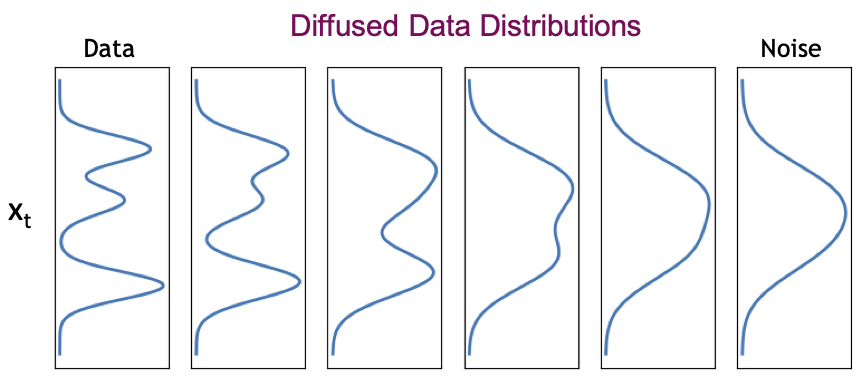

Основная идея генеративных диффузионных процессов состоит в том, чтобы шаг за шагом инвертировать описанный выше процесс прямой диффузии для получения точек данных, распределенных в соответствии с $\mu$, начиная со случайного гауссовского вектора, следующего распределению $\mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$.

Рассмотрим связь между диффузионными процессами и стохастическими дифференциальными уравнениями.

### Стохастические дифференциальные уравнения

В отличие от ОДУ (ODE), стохастические дифференциальные уравнения (СДУ, SDE) содержат дополнительный член в виде случайного процесса, т.е. семейства случайных величин. В частности, типичное СДУ можно записать как

$$ dX\left(t\right)=\mu\left(X\left(t\right),t\right)dt+\sigma\left(X\left(t\right),t\right)dW\left(t\right) $$

в так называемой нотации Ито, где коэффициент дрейфа $\mu:\mathbb{R}^{d}\times\left[0,\infty\right)\rightarrow\mathbb{R}^{d}$ является векторной функцией, а коэффициент диффузии $\sigma:\mathbb{R}^{d}\times\left[0,\infty\right)\rightarrow\mathbb{R}$ — вещественнозначной функцией. Кроме того, $X,W:\left[0,\infty\right)\rightarrow\mathbb{R}^{d}$ являются стохастическими процессами.

Часто, например, в финансовой математике или в физике элементарных частиц, $W$ моделируется как многомерное стандартное броуновское движение, т.е. как стохастический процесс, приращения которого $W(t_1)−W(t_0)$ независимы и распределены согласно закону $\mathcal{N}\left(\mathbf{0},\left(t_1−t_0\right)\mathbf{I}\right)$ при $t_1 >t_0 >0$.

 В контексте генеративных диффузионных моделей  мы рассматриваем SDE прямой диффузии
 
 $$dX\left(t\right)=-\frac{1}{2}\beta\left(t\right)X\left(t\right)dt+\sqrt{\beta\left(t\right)}dW\left(t\right) \tag{2}$$
 
 с некоторой дисперсией шума $\beta:\left[0,\infty\right)\rightarrow\mathbb{R}$. Для наших целей нас интересует не непрерывное во времени СДУ, а его дискретизация Эйлера–Маруямы, которая является стохастическим вариантом явной во времени схемы Эйлера. Используя размер временного шага $\Delta t > 0$, получаем
 
$$X\left(t+\Delta t\right)-X\left(t\right)=-\frac{1}{2}\beta\left(t\right)X\left(t\right)\Delta t+\sqrt{\beta\left(t\right)}\sqrt{\Delta t}\varepsilon,$$ 
 
где $\varepsilon\sim\mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$ — стандартная нормально распределённая случайная величина. Обратите внимание, что это можно переписать как

$$X\left(t+\Delta t\right)=\left(1-\frac{1}{2}\beta\left(t\right)\Delta t\right)X\left(t\right)+\sqrt{\beta\left(t\right)\Delta t}\varepsilon. \tag{3}$$
 

Теперь рассмотрим уравнение прямой диффузии с $ \boldsymbol{x}^{\left(i\right)} = X(i)$ и $\beta_{i} = β(i)\Delta t$, т.е.

$$ X\left(i+\Delta t\right)=\sqrt{1-\beta\left(i\right)\Delta t}X\left(i\right)+\sqrt{\beta\left(i\right)\Delta t}\varepsilon. $$

За исключением коэффициента дрейфа, т.е. члена перед $X(t)$ или $X(i)$ соответственно, оба уравнения одинаковы. Наконец, чтобы установить связь между этими уравнениями, отметим, что разложение Тейлора первого порядка для $\sqrt{1-\beta\left(i\right)\Delta t}$ в окрестности $\Delta t = 0$ даёт

$$\sqrt{1-\beta\left(i\right)\Delta t}=1-\frac{1}{2}\beta\left(i\right)\Delta t+O\left(\left(\Delta t\right)^{2}\right).$$

Таким образом, дискретизация Эйлера–Маруямы (3) уравнения прямой диффузии (2) напоминает дискретный процесс прямой диффузии (1) с точностью до второго порядка по $\Delta t$ при $\Delta t \rightarrow 0$.

### Процесс обратной диффузии

Чтобы получить выборку в соответствии с распределением данных $\mu$, нам необходим процесс обратной диффузии 
$\bar{X}$, который (приблизительно) преобразует точку $\boldsymbol{x}^{\left(T\right)}$, вычисленную согласно процессу прямой диффузии для очень больших $T > 0$, обратно в начальное значение $\boldsymbol{x}^{\left(0\right)}$. Можно доказать, что процесс прямой диффузии можно обратить во времени и решение задаётся формулой

$$d\bar{X}\left(t\right)=-\frac{1}{2}\beta\left(t\right)\left(\bar{X}\left(t\right)+g\left(\bar{X}\left(t\right),t\right)\right)dt+\sqrt{\beta\left(t\right)}d\bar{W}\left(t\right) \tag{4}$$

для некоторой функции $g:\mathbb{R}^{d}\times\left[0,\infty\right)\rightarrow\mathbb{R}^{d}$. Здесь $dt$ следует понимать как бесконечно малый шаг назад во времени, а $\bar{W}$ — броуновское движение, обращенное во времени. Применяя дискретизацию Эйлера–Маруямы с шагом по времени $\Delta t$ к этому обратному СДУ, получаем

$$ \bar{X}\left(t-\Delta t\right)=\bar{X}\left(t\right)-\frac{1}{2}\beta\left(t\right)\Delta t\left(\bar{X}\left(t\right)+g\left(\bar{X}\left(t\right),t\right)\right)+\sqrt{\beta\left(t\right)\Delta t}\varepsilon $$

для $\varepsilon\sim\mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$. Это показывает, что как для дискретизированного прямого диффузионного уравнения (SDE), так и для дискретизированного обратного диффузионного уравнения (BSDE) нам достаточно вычислить только члены, зависящие от текущей итерации, и небольшое гауссовское приращение для получения следующей итерации. Фактически, это также применимо к процессу обратной диффузии. В частности, поскольку распределение $\boldsymbol{x}^{\left(i\right)}$ при заданном $\boldsymbol{x}^{\left(i-1\right)}$ можно записать как

$$p^{*}\left(\boldsymbol{x}^{\left(i\right)}\mid\boldsymbol{x}^{\left(i-1\right)}\right)\sim\mathcal{N}\left(\sqrt{1-\beta_{i}}\boldsymbol{x}^{\left(i-1\right)},\beta_{i}\mathbf{I}\right),$$

можно показать, что (истинное) распределение $\boldsymbol{x}^{\left(i-1\right)}$ при данных $\boldsymbol{x}^{\left(i\right)}$ и $\boldsymbol{x}^{\left(0\right)}$ можно записать как

$$p^{*}\left(\boldsymbol{x}^{\left(i-1\right)}\mid\boldsymbol{x}^{\left(i\right)},\boldsymbol{x}^{\left(0\right)}\right)\sim\mathcal{N}\left(\bar{\boldsymbol{m}}_{i},\bar{\sigma}_{i}\mathbf{I}\right),$$

где как среднее значение $\bar{\boldsymbol{m}}_{i}$, так и уровень шума $\bar{\sigma}_{i}$ зависят только от $\boldsymbol{x}^{\left(i\right)}$, $\boldsymbol{x}^{\left(0\right)}$ и $\beta_j$ при $1\leqslant j\leqslant i$. 

Поскольку $\boldsymbol{x}^{\left(0\right)}$ неизвестен при обращении процесса прямой диффузии для вывода $\boldsymbol{x}^{\left(i-1\right)}$ из $\boldsymbol{x}^{\left(i\right)}$,
мы аппроксимируем распределение $p^{*}\left(\boldsymbol{x}^{\left(i-1\right)}\mid\boldsymbol{x}^{\left(i\right)},\boldsymbol{x}^{\left(0\right)}\right)$ следующим образом:

$$p\left(\boldsymbol{x}^{\left(i-1\right)}\mid\boldsymbol{x}^{\left(i\right)}\right)\sim\mathcal{N}\left(\boldsymbol{m}_{i},\sigma_{i}\mathbf{I}\right)$$

со степенями свободы $\boldsymbol{m}_{i}$ и $\sigma_{i}$, не зависящими от $\boldsymbol{x}^{\left(0\right)}$. Часто
коэффициенты дисперсии фиксированы априори, например, $\sigma_{i}=\beta_i$. Это означает, что нам остаётся определить $\boldsymbol{m}_{i}$ по заданным данным $\boldsymbol{x}_1,...,\boldsymbol{x}_n$. Для этого мы создаём нейронную сеть, принимающую $\boldsymbol{x}^{\left(i\right)}$  на входе и вычисляющую $\boldsymbol{m}_{i}$ на выходе. Для обучения сети можно рассмотреть минимизацию перекрёстной энтропии

$$-\mathbb{E}_{p^{*}\left(\boldsymbol{x}^{\left(0\right)}\right)}\left[p\left(\boldsymbol{x}^{\left(0\right)}\right)\right] \tag{5}$$

на заданных обучающих данных, т.е. ожидаемое значение $\mathbb{E}_{p^{*}\left(\boldsymbol{x}^{\left(0\right)}\right)}$ станет средним по $\boldsymbol{x}_1,...,\boldsymbol{x}_n$. Однако, поскольку $p\left(\boldsymbol{x}^{\left(0\right)}\right)$  недоступно напрямую, мы следуем идее потерь ELBO для вариационных автокодеров. Таким образом, вместо минимизации перекрёстной энтропии (5) для получения $\boldsymbol{m}_{1},...,\boldsymbol{m}_{T}$, мы минимизируем ELBO

$$\mathbb{E}_{p^{*}}\left[\log\left(p^{*}\left(\boldsymbol{x}^{\left(T\right)}\right)\right)+\sum_{i=1}^{T}\log\left(\frac{p\left(\boldsymbol{x}^{\left(i-1\right)}\mid\boldsymbol{x}^{\left(i\right)}\right)}{p^{*}\left(\boldsymbol{x}^{\left(i\right)}\mid\boldsymbol{x}^{\left(i-1\right)}\right)}\right)\right], \tag{6}$$

где $T > 0$ — число шагов процесса прямой диффузии.

Наконец, мы видим, что после изучения $\boldsymbol{m}_{i}$ оба процесса прямой диффузии

$$\boldsymbol{x}^{\left(i\right)}=\sqrt{1-\beta_{i}}\boldsymbol{x}^{\left(i-1\right)}+\sqrt{\beta_{i}}\varepsilon_i$$

и обратной диффузии

$$\boldsymbol{x}^{\left(i-1\right)}=\boldsymbol{m}_{i}+\sqrt{\sigma_{i}}\bar{\varepsilon}_{i},$$

где $\varepsilon_i, \bar{\varepsilon}_{i}\sim\mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$ вычисляются путем выборки из стандартных нормальных распределений. 
Это аналогично дискретизациям Эйлера–Маруямы соответствующих прямых и обратных диффузионных СДУ.

### Обучение и генерация

Как уже упоминалось, мы фиксируем дисперсии $\sigma_{i}$ для $i = 1,...,T$, например, как $\sigma_{i}=\beta_i$, и используем нейронную сеть для определения $\boldsymbol{m}_{i}$ для заданного $\boldsymbol{x}^{\left(i\right)}$. Для обучения этой сети мы минимизируем функцию потерь ELBO (6) на наборе обучающих данных $\boldsymbol{x}_1,...,\boldsymbol{x}_n$ с помощью алгоритма типа SGD. Для этого нам необходимо иметь возможность оценить ELBO, аппроксимированную выражением

$$\frac{1}{n}\sum_{j=1}^{n}\left(\log\left(p^{*}\left(\boldsymbol{x}_{j}^{\left(T\right)}\right)\right)+\sum_{i=1}^{T}\log\left(\frac{p\left(\boldsymbol{x}_{j}^{\left(i-1\right)}\mid\boldsymbol{x}_{j}^{\left(i\right)}\right)}{p^{*}\left(\boldsymbol{x}_{j}^{\left(i\right)}\mid\boldsymbol{x}_{j}^{\left(i-1\right)}\right)}\right)\right), \tag{7}$$

т.е. мы вычисляем среднее значение по заданным обучающим данным. Для оценки выражения предположим, что $T$  достаточно велико, чтобы $\boldsymbol{x}_j^{\left(T\right)}$ (приблизительно) подчинялось стандартному нормальному закону распределения, т.е. предположим, что $p^{*}\left(\boldsymbol{x}_j^{\left(T\right)}\right)\sim\mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$
для всех $j = 1,...,n$. 
Кроме того, отметим, что $p^{*}\left(\boldsymbol{x}_{j}^{\left(i\right)}\mid\boldsymbol{x}_{j}^{\left(i-1\right)}\right)$ известно, т.е. мы можем его вычислить. 
Таким образом, мы можем вычислить $\boldsymbol{x}_{j}^{\left(i\right)}$ для каждого $i = 1,...,T$ и для каждой
$j$-й точки обучающих данных $\boldsymbol{x}_{j}$, $j = 1,...,n$, делая выборки из $\mathcal{N}\left(\sqrt{1-\beta_{i}}\boldsymbol{x}^{\left(i-1\right)},\beta_{i}\mathbf{I}\right)$, и, таким образом, можем
вычислить аппроксимирующее выражение для ELBO.

Наконец, предполагая, что 
$p^{*}\left(\boldsymbol{x}^{\left(T\right)}\right)\sim\mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$, 
мы минимизируем выражение для ELBO относительно весов
и смещений сети с помощью алгоритма типа SGD.

Чтобы использовать уже обученный генеративный процесс диффузии для генерации данных, мы просто берём
случайный вектор $\boldsymbol{x}^{\left(T\right)}\sim\mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$, вычисляем соответствующий вектор $\boldsymbol{m}_{T}$ с помощью обученной нейронной сети 
и применяем распределение $\mathcal{N}\left(\boldsymbol{m}_{i},\sigma_{i}\mathbf{I}\right)$ для $i = T$, чтобы получить $\boldsymbol{x}^{\left(T-1\right)}$. Этот процесс вычисления $\boldsymbol{m}_{i}$ и применения $\mathcal{N}\left(\boldsymbol{m}_{i},\sigma_{i}\mathbf{I}\right)$ затем повторяется для $i = T − 1,..., 1$, чтобы в итоге получить новую точку данных $\boldsymbol{x}^{\left(0\right)}$.

# Одномерная вероятностная модель диффузии с шумоподавлением
 

In [1]:
import os

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # added for torch

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from numpy import random
import random as rd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
device_str = \
    "cuda" if torch.cuda.is_available() else \
    "mps"  if torch.backends.mps.is_available() else \
    "cpu"
device = torch.device(device_str)

print(f"Device: {device}")

Device: mps


Мы генерируем 2000 случайных чисел с произвольным распределением.

In [49]:
x0 = -np.random.poisson(8, 1000) # numpy.random.poisson(lam, size=None)
x0 = np.append(x0,np.random.poisson(1, 800))
x0 = np.append(x0,np.random.rand(200)+15)
x0 = x0/4

np.random.shuffle(x0)                         #shuffle initial data
x_0 = torch.tensor(x0).to(torch.float32).to(device) 
len_data = len(x_0)
x_0[:5]

tensor([ 0.2500,  0.0000, -0.7500, -1.0000, -2.5000], device='mps:0')

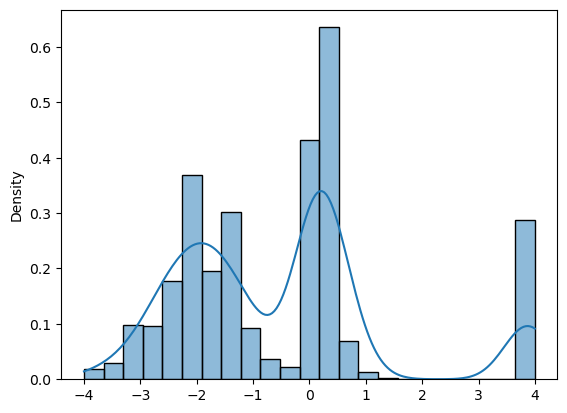

In [50]:
sns.histplot(x0, stat="density", kde="True"); #plot the distribution

Теперь определим значения $T, \beta_t, \alpha_t, \overline \alpha_t$ для любого $t \in \{0,\dots, T\}$, где 

$$\alpha_{t}=1-\beta_{t},\bar{\alpha}_{t}=\prod_{s=1}^{t}\alpha_{s}.$$

Этот выбор параметров был сделан тщательно эмпирически, экспериментально, чтобы определить наилучший вариант. 

In [5]:
beta_0 = .0004
beta_T = .06
T = 100

#the betas grows linearly from beta0 to betaT
betas = np.linspace(beta_0, beta_T, T)     
alphas = 1 - betas

betas = torch.tensor(betas).to(torch.float32).to(device)
alphas = torch.tensor(alphas).to(torch.float32).to(device)
    
list_bar_alphas = torch.cumprod(alphas, axis=0).\
    to(torch.float32).to(device)

## Прямой процесс «зашумления»

Теперь мы определим функцию, которая дает нам $x_t$ при заданном $x_0$ благодаря формуле $x_t(x_0)=\sqrt{\overline \alpha_t} x_0 + \sqrt{1-\overline \alpha_t}z$

In [6]:
def p_forward(x_time0, t, bar_alphas, device):

    alpha_bar_t = bar_alphas[t]
    
    mean = torch.sqrt(alpha_bar_t)*x_time0
    sigma2 = torch.eye(x_time0.shape[0]).to(device)
    sigma2 = sigma2*(1-alpha_bar_t)
    return torch.distributions.MultivariateNormal(mean,sigma2).\
        sample().to(device)

Теперь построим график изменения распределения $p(x_ 0)$ во времени, используя приведённую выше функцию. Видно, что $p(x_T) \sim \mathcal{N}(0,1)$.

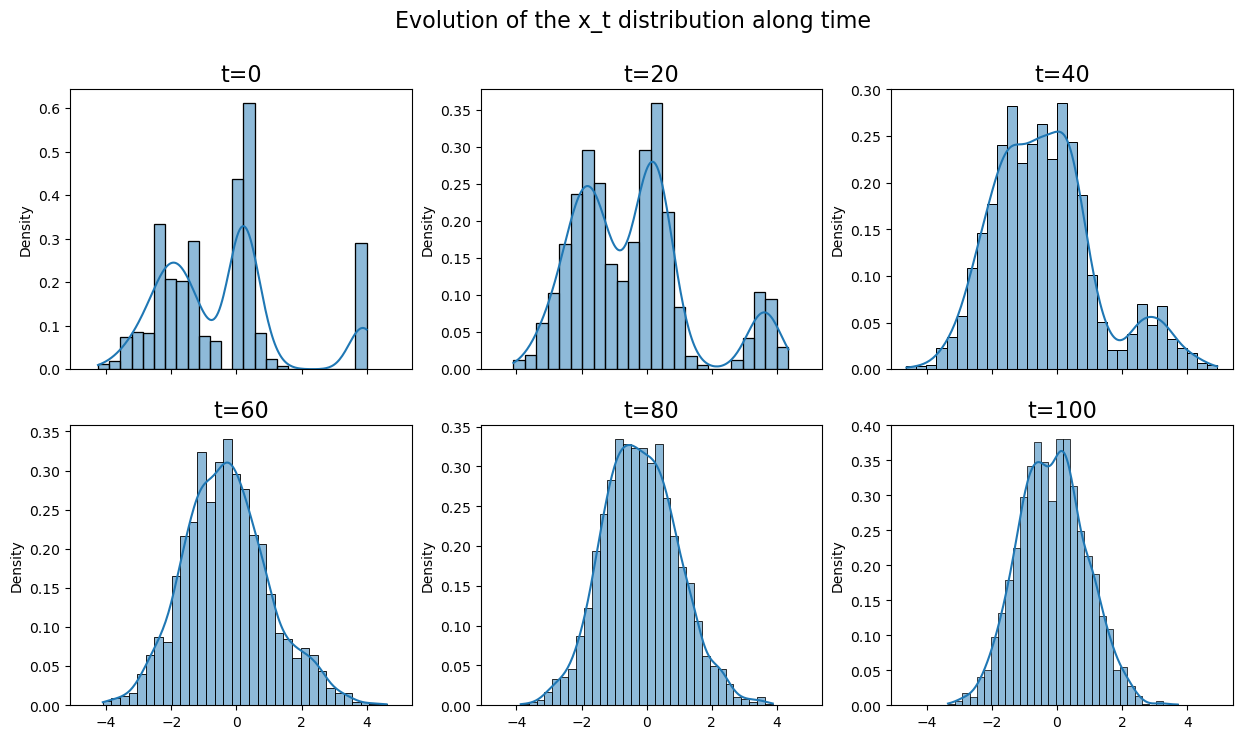

In [47]:
fig, axes = plt.subplots(2, 3, sharex=True, figsize=(15,8))
fig.suptitle(
    'Evolution of the x_t distribution along time', fontsize=16
)
sns.histplot(x_0.cpu(),stat="density", kde="True", ax=axes[0][0])
axes[0][0].set_title('t=0',fontsize=16)
sns.histplot(p_forward(x_0, 20, list_bar_alphas, device).cpu(),
             stat="density", kde="True", ax=axes[0][1])
axes[0][1].set_title('t=20', fontsize=16)
sns.histplot(p_forward(x_0, 40, list_bar_alphas, device).cpu(),
             stat="density", kde="True", ax=axes[0][2])
axes[0][2].set_title('t=40', fontsize=16)
sns.histplot(p_forward(x_0, 60, list_bar_alphas, device).cpu(),
             stat="density", kde="True", ax=axes[1][0])
axes[1][0].set_title('t=60', fontsize=16)
sns.histplot(p_forward(x_0, 80, list_bar_alphas, device).cpu(),
             stat="density", kde="True", ax=axes[1][1])
axes[1][1].set_title('t=80', fontsize=16)
sns.histplot(p_forward(x_0, 99, list_bar_alphas, device).cpu(),
             stat="density", kde="True", ax=axes[1][2])
axes[1][2].set_title('t=100', fontsize=16);

Мы также можем построить траектории для некоторого количества точек распределения $p(x_0)$. Мы увидим, что, начиная с нашего произвольного распределения $p(x_0)$, траектории сходятся к некоторой точке, симметричной относительно $0$, точно так же, как точки, распределенные как $\mathcal{N}(0,1)$.

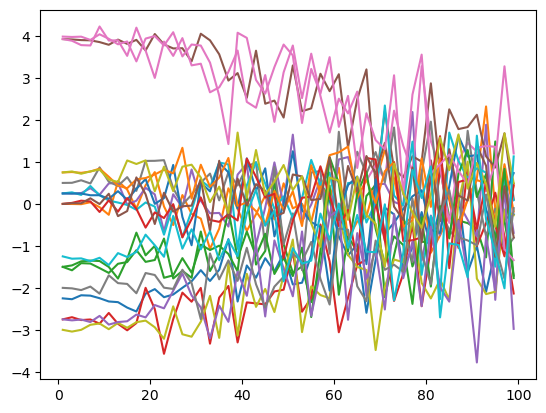

In [8]:
indts=[rd.randrange(0, len_data-1) for j in range(20)]
xx0=[]
tt=range(1,T,2)
xx0.append(x0[indts])
for t in tt:
    xx0.append(p_forward(x_0[indts], t, list_bar_alphas, device).\
               cpu().detach().numpy())
plt.plot(tt,xx0[:len(tt)]);

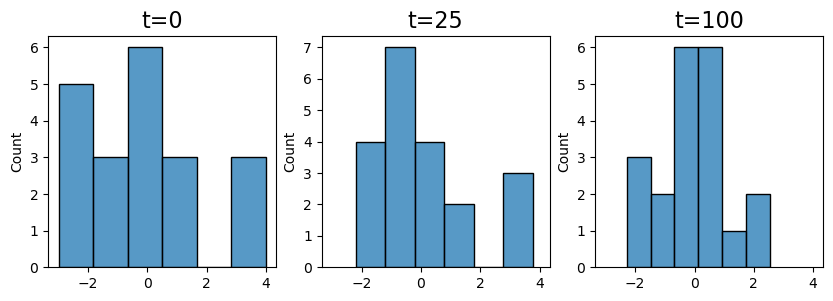

In [9]:
fig, axes = plt.subplots(1,3, sharex=True, figsize=(10,3))
sns.histplot(xx0[0],stat="count", ax=axes[0])
axes[0].set_title('t=0',fontsize=16)
sns.histplot(xx0[25],stat="count", ax=axes[1])
axes[1].set_title('t=25', fontsize=16)
sns.histplot(xx0[len(xx0)-1],stat="count", ax=axes[2])
axes[2].set_title('t=100', fontsize=16);

## Оценка процесса шумоподавления

Сначала определим функцию, которая по заданным $x_t, t, x_0$ вычисляет $\tilde \mu(x_t)$, что является средним значением распределения $p(x_{t-1}|x_t,x_0)$, вычисленного аналитически. Мы могли бы также вычислить $\tilde \sigma_t$, но это не обязательно.

In [10]:
def tildemu(x_time0, x_t, t, alphas, bar_alphas, device):
    beta_t = 1 - alphas[t]
    alpha_t = alphas[t]
    alpha_bar_t = bar_alphas[t]
    alpha_bar_tminus1 = bar_alphas[t-1]
    
    tilde_mu= x_time0 * torch.sqrt(alpha_bar_tminus1) * \
        beta_t / (1 - alpha_bar_t) + \
        x_t * torch.sqrt(alpha_t)*(1 - alpha_bar_tminus1)/ \
        (1 - alpha_bar_t)
      
    return tilde_mu

Определим нейронную модель, целью которой будет оценка $\mu_{\theta}(x_t)$ таким образом, чтобы минимизировать среднеквадратичную ошибку (СКО) между ней и $\tilde \mu(x_t)$ на наших данных для случайно выбранных моментов времени $t$. Это станет более понятно, когда мы определим сеанс обучения. Сначала мы определим позиционный энкодер, а затем простую нейронную архитектуру. Модель, безусловно, можно значительно улучшить, но это выходит за рамки нашей задачи продемонстрировать и сделать понятной основную особенность этих процессов.

In [11]:
def position_encoding_init(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(10000, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return torch.from_numpy(P).to(torch.float32)

In [12]:
class Denoise(torch.nn.Module):

    def __init__(self, len_x, T):
        super(Denoise, self).__init__()

        self.linear1 = torch.nn.Linear(len_x, len_x)
        self.emb = position_encoding_init(T,len_x)
        self.linear2 = torch.nn.Linear(len_x, len_x)
        self.linear3 = torch.nn.Linear(len_x, len_x)
        self.relu = torch.nn.ReLU()

    def forward(self, input_x, t):
        emb_t = self.emb[t]
        x = self.linear1(input_x+emb_t)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        return x

Теперь определим параметры, используемые для обучения.

In [13]:
times_used_per_epoch= 400      
# at each epoch it will take this number of time step to evaluate 
# the MSE and minimizing it
num_epochs=20

criterion = nn.MSELoss()
model = Denoise(len_data, T).to(device)
model.emb = model.emb.to(device)
optimizer = optim.AdamW(model.parameters())

Обучаем модель:

In [14]:
pbar= tqdm(range(num_epochs), ncols=68)

for epoch in pbar: 
    running_loss = 0.0
    times = np.random.randint(1,T, times_used_per_epoch)

    for _, t in enumerate(times):

        x_t = p_forward(x_0, t, list_bar_alphas, device)
                
        tilde_mu_t = tildemu(
            x_0, x_t, t, alphas, list_bar_alphas, device
        )
        optimizer.zero_grad()
  
        mu_theta_t = model(x_t , t)
        loss = criterion(tilde_mu_t, mu_theta_t)
        loss.backward()
        optimizer.step()
        running_loss += loss.detach()
    pbar.set_description('Epoch: {} Loss: {:.4f}'.format(
        epoch, running_loss/times_used_per_epoch
    ))
print('Finished Training')

Epoch: 19 Loss: 0.4737: 100%|███████| 20/20 [02:37<00:00,  7.85s/it]

Finished Training


## Обратный процесс «шумоподавления»

Определим здесь обратный процесс как $x_{t-1}=\mu_{\theta}(x_t)+\sqrt{\beta_t} z_t$, т.е. $x_{t-1}$ генерируется из $\mathcal{N}(\mu_{\theta}(x_t), \beta_t I)$.

In [15]:
def reverse_process(
    model_used, x_t, t, alphas, bar_alphas, len_x, device
):
    beta_t = 1 - alphas[t]
    alpha_t = alphas[t]
    alpha_bar_t = bar_alphas[t]
    alpha_bar_tmin1 = bar_alphas[t-1]
    
    mu_theta_t = model_used(x_t,t)
    
    var=beta_t      #*(1-alpha_bar_tmin1)/(1-alpha_bar_t)
    
    # We chose as variance for the reverse process the matrix beta_t, 
    # but it is an arbitrary choice, we used the one suggested 
    # in literature
    x_tminus1 = torch.distributions.MultivariateNormal(
        mu_theta_t, torch.diag(var.repeat(len_x))
    ).sample().to(device)
        
    return x_tminus1

Теперь мы моделируем этот обратный процесс и строим графики распределений, идущих назад во времени, а также некоторые траектории.

In [16]:
rev=[]
rev.append(torch.distributions.MultivariateNormal(
    torch.zeros(len_data),torch.eye(len_data)
).sample().to(device))

for t in tqdm(range(T), ncols=68):
    rev.append(reverse_process(
        model,rev[t],T-t-1, alphas, list_bar_alphas, len_data, device
    ))

100%|█████████████████████████████| 100/100 [00:01<00:00, 63.41it/s]


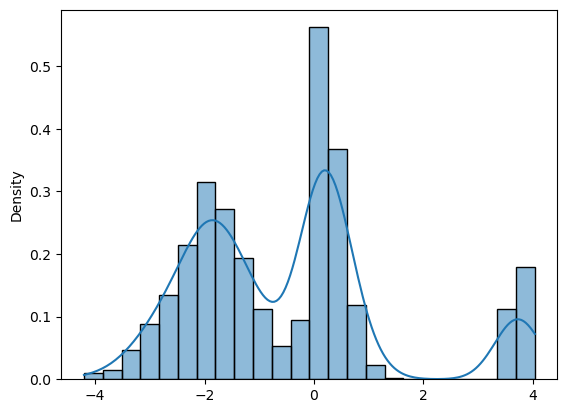

In [17]:
sns.histplot(rev[99].cpu(), stat="density", kde="True");

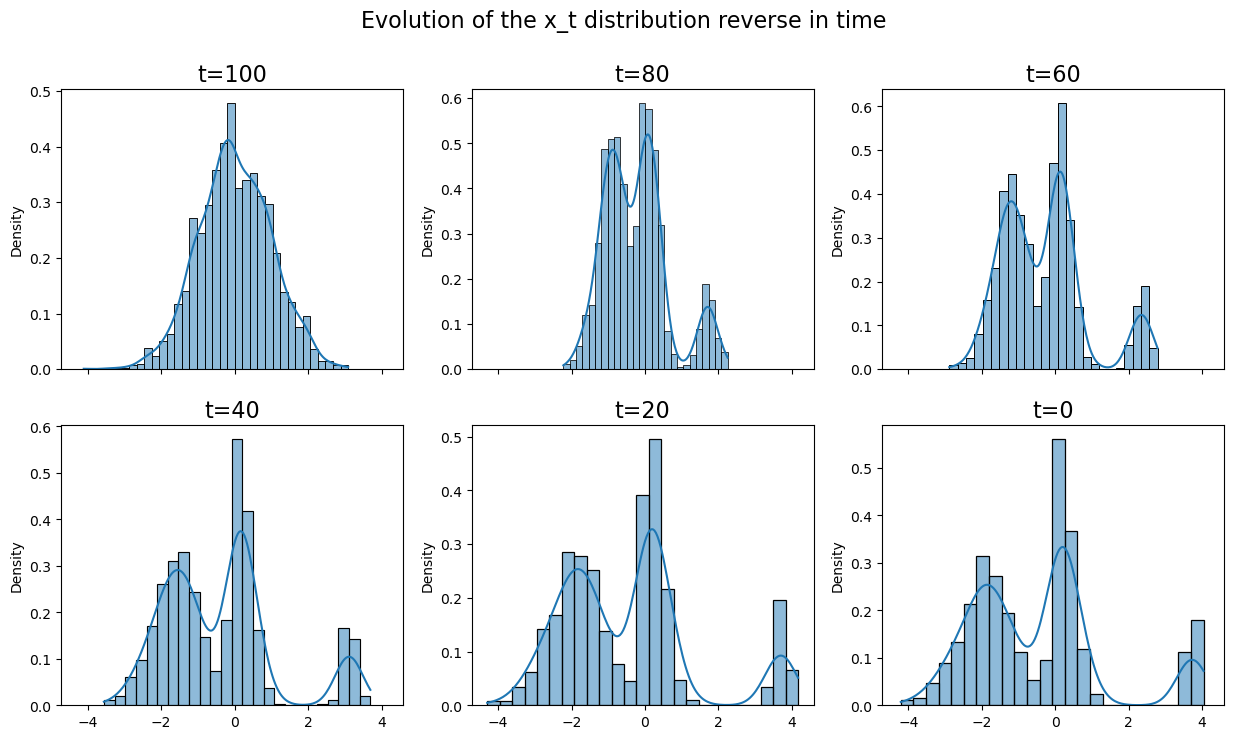

In [18]:
fig, axes = plt.subplots(2, 3, sharex=True, figsize=(15,8))
fig.suptitle(
    'Evolution of the x_t distribution reverse in time', fontsize=16
)
sns.histplot(rev[0].cpu(), stat="density", kde="True", ax=axes[0][0])
axes[0][0].set_title('t=100',fontsize=16)
sns.histplot(rev[20].cpu(), stat="density", kde="True", ax=axes[0][1])
axes[0][1].set_title('t=80', fontsize=16)
sns.histplot(rev[40].cpu(), stat="density", kde="True", ax=axes[0][2])
axes[0][2].set_title('t=60', fontsize=16)
sns.histplot(rev[60].cpu(), stat="density", kde="True", ax=axes[1][0])
axes[1][0].set_title('t=40', fontsize=16)
sns.histplot(rev[80].cpu(), stat="density", kde="True", ax=axes[1][1])
axes[1][1].set_title('t=20', fontsize=16)
sns.histplot(rev[99].cpu(), stat="density", kde="True", ax=axes[1][2])
axes[1][2].set_title('t=0', fontsize=16);

Мы строим несколько обратных траекторий, начиная с 20 случайных точек, взятых из распределения $\mathcal{N}(0,1)$. Очевидно, что процесс «выбирает» путь уже на первых этапах.

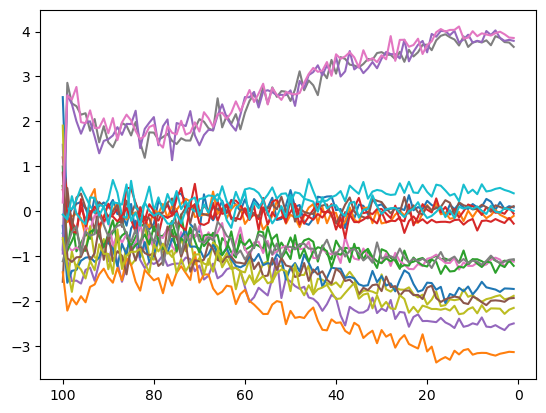

In [19]:
from pylab import *

indts2=[rd.randrange(0, len_data-1) for j in range(20)]
tt2=range(T)
#label=[]
back=[ [] for _ in range(T)]
for j in range(20):
    for t in range(T):
        back[t].append(rev[t][indts2[j]].cpu())
        #label.append(str(T-t))

# Time in original order: 0,20,...,T
time_original = list(range(0, T+1, 20))
# But we want x-axis to show reversed: T, T-20, ..., 0
time_reversed_labels = [str(T - t) for t in time_original]

axes = figure().add_subplot(111)
axes.plot(tt2,back)

# Set custom x-tick labels to show reversed time
axes.set_xticks(time_original)
axes.set_xticklabels(time_reversed_labels)

plt.show()

## Условные плотности

Оценим условные плотности $p(x_{t-1}|x_t)$, используя $\mu_{\theta}$, которые дала нам наша модель, т. е. $\mathcal{N}(\mu_{\theta}(x_t), \beta_t I)$, и значения $x_t, x_{t-1}$ в интервале $[-1,1]$.

In [20]:
#analytical density function for a normal of the form that we found
def cond_dens(model_used, x_tminus1, x_t, t, betas):    
    sqrtbeta_t=torch.sqrt(betas[t])
    mu_theta_t=model_used(x_t,t)
    A=(sqrt(2*np.pi)*sqrtbeta_t)**(-1)
    B= -0.5*((x_tminus1-x_t)/sqrtbeta_t)**2
    f = A*torch.exp(B)
    return f

In [21]:
ax_xt=torch.tensor(np.linspace(-1, 1, len_data)).\
    to(torch.float32).to(device)

prob_dens=[ [] for _ in range(T)]
for tx in tqdm(range(T), ncols=68):
    for x_tminus1 in ax_xt:
        prob_dens[tx].append(
            cond_dens(model, x_tminus1, ax_xt,  
                      torch.tensor(tx).to(device), betas).\
            cpu().detach().numpy()
        )

100%|█████████████████████████████| 100/100 [03:42<00:00,  2.22s/it]


In [22]:
list_prob=[]
for tx in tqdm(range(T), ncols=68):
    list_prob.append(np.array([l.tolist() for l in prob_dens[tx]]))

100%|█████████████████████████████| 100/100 [00:16<00:00,  5.99it/s]


In [23]:
ixti=ax_xt.cpu().detach().numpy()
list_prob[1].shape

(2000, 2000)

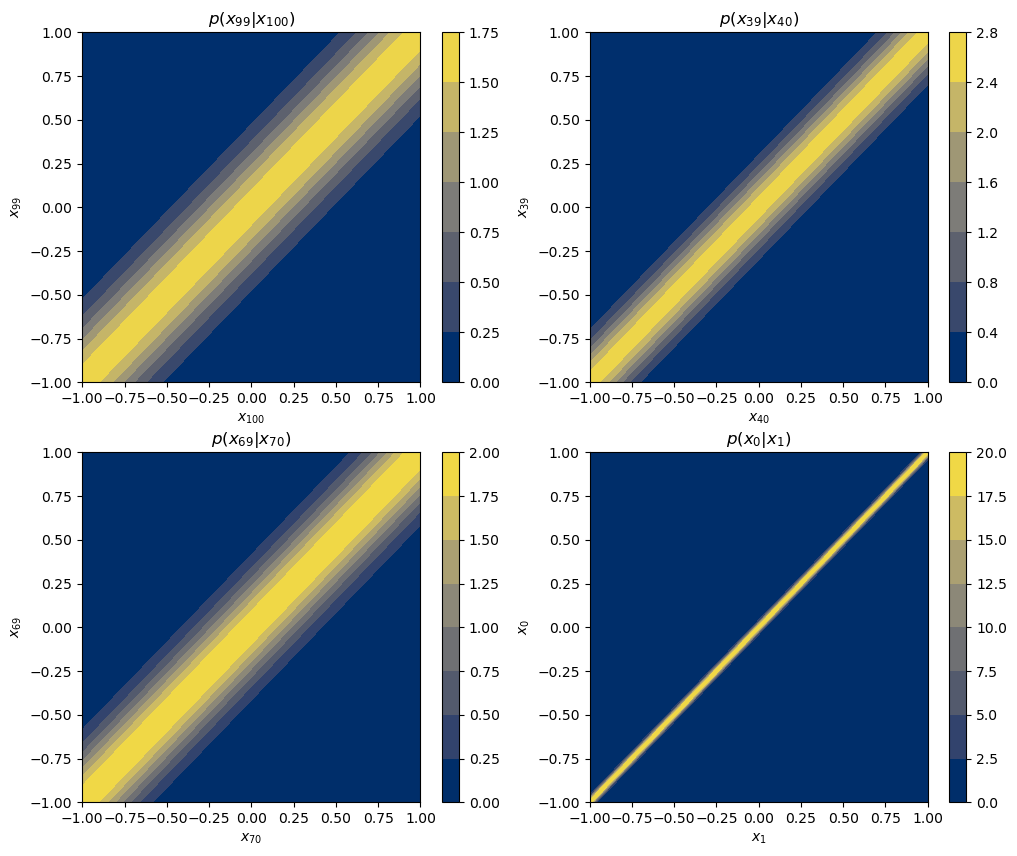

In [24]:
X, Y = meshgrid(ixti,ixti)
fig, axs = plt.subplots(2, 2, figsize=(12,10))
ttt=[99, 69, 39, 0]
i=0
for col in range(2):
    for row in range(2):
        ax = axs[row, col]
        pcm = ax.contourf(X,Y,list_prob[ttt[i]], cmap='cividis')
        ax.set(xlabel='$x_{}$'.format('{'+str(ttt[i]+1)+'}'), 
               ylabel='$x_{}$'.format('{'+str(ttt[i])+'}'), 
               title='$p(x_{}|x_{})$'.format('{'+str(ttt[i])+'}',
                                             '{'+str(ttt[i]+1)+'}'))
        fig.colorbar(pcm, ax=ax)
        i=i+1

## Частоты и совместные вероятности

В этом разделе проанализируем эмпирические распределения вида $p(x_{t'}, x_t)$, полученные с помощью оцененных нами траекторий.

In [25]:
print(max(rev[0]), min(rev[0]))

tensor(3.0882, device='mps:0') tensor(-4.1090, device='mps:0')


In [26]:
quant=40
#discretizing the interval in which the x_t s take values 
xx0=linspace(-5.5,5.5,quant)     
XX, YY = meshgrid(xx0,xx0)

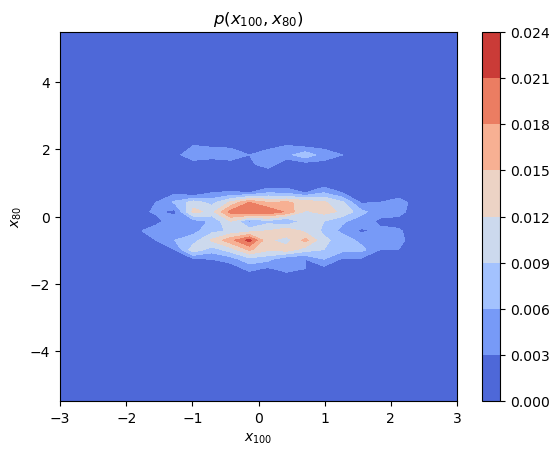

In [27]:
tempo2=80           #t'
tempo1=100           #t

rev_t1=T-tempo1    
rev_t2=T-tempo2
aa=rev[rev_t1].cpu().detach().numpy() 
bb=rev[rev_t2].cpu().detach().numpy()
freq=np.zeros((quant,quant))      

for i in range(len(aa)):
    j=0
    jb=0
    while aa[i]>xx0[j]:
        if j>quant-2:
            break
        j=j+1
    while bb[i]>xx0[jb]:
        if jb>quant-2:
            break
        jb=jb+1
    freq[jb][j]=freq[jb][j]+1


fig = plt.figure()
ax = fig.add_subplot(111)

surf = ax.contourf(XX, YY, freq/sum(freq), cmap=cm.coolwarm,)
ax.set_xlim(-3, 3)
ax.set(xlabel='$x_{}$'.format('{'+str(tempo1)+'}'), 
       ylabel='$x_{}$'.format('{'+str(tempo2)+'}'), 
       title='$p(x_{},x_{})$'.format('{'+str(tempo1)+'}',
                                     '{'+str(tempo2)+'}'))
fig.colorbar(surf)

plt.show()

Ниже создадим видео с графиками, полученными при фиксированном $t=100$ и изменении $t'$ от $99$ до $0$. Можно увидеть, как выглядит итоговое распределение.

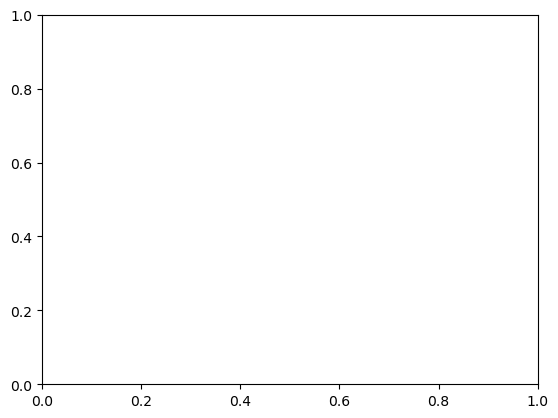

In [28]:
tempo1=T
rev_t1=T-tempo1
aa=rev[rev_t1].cpu().detach().numpy()

quant=40
#discretizing the interval in which the x_t s take values 
xx0=linspace(-5.5,5.5,quant)     
XX, YY = meshgrid(xx0,xx0)


fig, ax = plt.subplots()
 
for t in range(1,T):
     
    # clear
    freq=np.zeros((quant,quant))
    
    tempo2=t
    #frequencies tab
    rev_t2=T-t
    bbt=rev[tempo2].cpu().detach().numpy()
    for i in range(len(aa)):
        j=0
        jb=0
        while aa[i]>xx0[j]:
            if j>quant-2:
                break
            j=j+1
        while bbt[i]>xx0[jb]:
            if jb>quant-2:
                break
            jb=jb+1
        freq[jb][j]=freq[jb][j]+1

#    ax.clear()
    fig = plt.figure()
    ax = fig.add_subplot(111)
    surf=ax.contourf(XX, YY, freq/sum(freq), cmap=cm.coolwarm,)
    ax.set_xlim(-3, 3)
    ax.set(xlabel='$x_{}$'.format('{'+str(tempo1)+'}'), 
           ylabel='$x_{}$'.format('{'+str(rev_t2)+'}'), 
           title='$p(x_{},x_{})$'.format('{'+str(tempo1)+'}',
                                         '{'+str(rev_t2)+'}'))
    #fig.colorbar(surf)
    # returning numpy image
    fig.savefig('./plotsLast/{}.png'.format(t))
    plt.close(fig)

In [29]:
# pip install moviepy
#from moviepy import VideoClip

#animation = VideoClip(make_frame, duration = duration)

#animation.ipython_display(fps = 2, loop = True, autoplay = True)

In [30]:
import os
import glob
from natsort import natsorted
from moviepy import *


gif_name = 'pic'
fps = 24

# Get all the pngs in the current directory
file_list = glob.glob('./plotsLast/*.png')  
# Sort the images
file_list_sorted = natsorted(file_list,reverse=False)  

clips = [ImageClip(m, duration=0.25)
         for m in file_list_sorted]

len(file_list_sorted)
concat_clip = concatenate_videoclips(clips, method="chain")
concat_clip.write_videofile("LastVideo.mp4", fps=fps)

MoviePy - Building video LastVideo.mp4.
MoviePy - Writing video LastVideo.mp4



MoviePy - Done !
MoviePy - video ready LastVideo.mp4


In [31]:
from IPython.display import Video

Video("LastVideo.mp4")

## GMM (Gaussian Mixture Model) — модель гауссовской смеси

В этом разделе мы моделируем совместное распределение вероятностей $p(x_0, x_{100})$ как комбинацию гауссовых случайных распределений.

In [32]:
from sklearn import mixture
x100=rev[0].cpu().detach().numpy()
x0=rev[len(rev)-1].cpu().detach().numpy()

X=np.array([x100,x0]).T

Text(0, 0.5, 'x0')

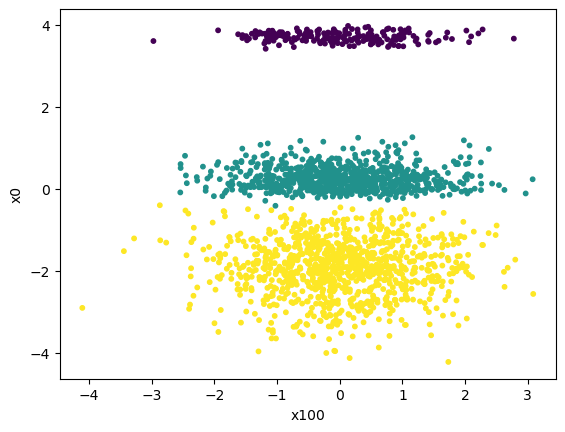

In [33]:
GMM = mixture.GaussianMixture(n_components=3, covariance_type='full')
gmm = GMM.fit(X)
labels = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap='viridis')
plt.xlabel("x100")
plt.ylabel("x0");

Ниже создадим новую выборку из распределения, которое мы только что оценили, и посмотрим, соответствует ли она, по крайней мере графически, распределению, найденному с помощью предыдущих симуляций.

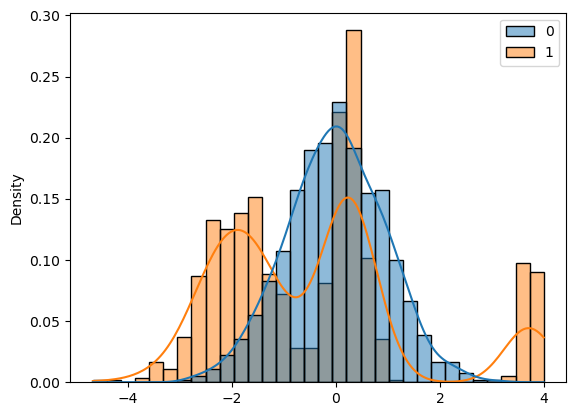

In [34]:
data_new = gmm.sample(1000)
#plot the distribution
sns.histplot(data_new[0], stat="density", kde="True")    
generated=data_new[0]

generatedx0=[]
X_gen=[]
for i in enumerate(generated):
    generatedx0.append(i[1][1])
    X_gen.append(i[1][0])

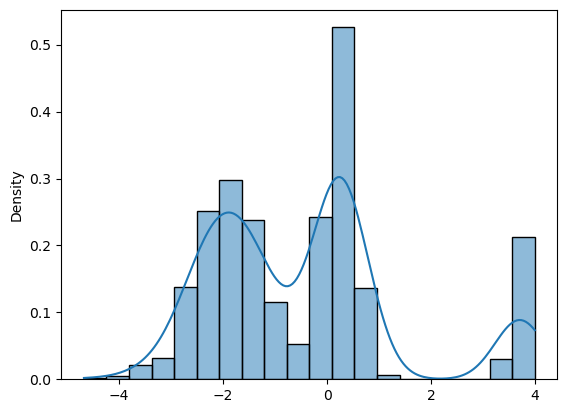

In [35]:
sns.histplot(generatedx0, stat="density", kde="True");

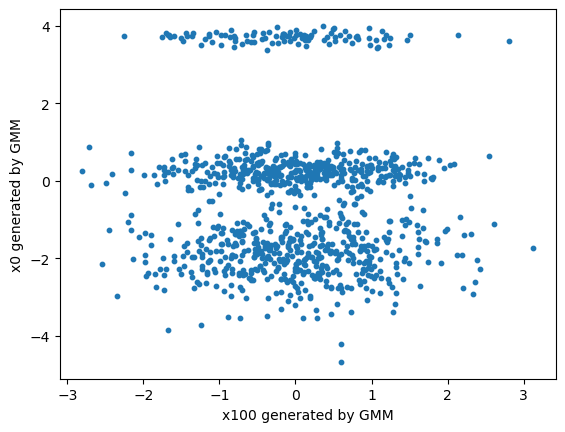

In [36]:
plt.scatter(X_gen, generatedx0, s=10)
plt.xlabel("x100 generated by GMM")
plt.ylabel("x0 generated by GMM");

Ниже используем тот же подход для моделирования $p(x_{100}-x_0,x_0)$.

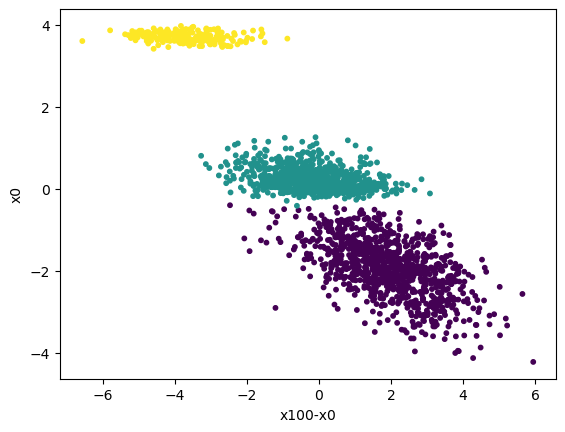

In [37]:
XX=np.array([x100-x0,x0]).T

GMM2 = mixture.GaussianMixture(n_components=3, covariance_type='full')
gmm2 = GMM2.fit(XX)
labels = gmm2.predict(XX)
plt.scatter(XX[:, 0], XX[:, 1], c=labels, s=10, cmap='viridis')
plt.xlabel("x100-x0")
plt.ylabel("x0");

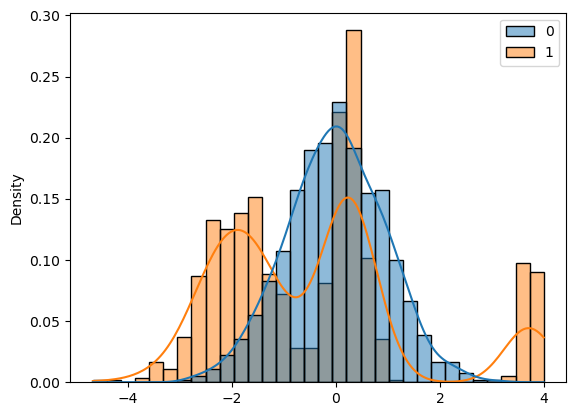

In [38]:
data_new2 = gmm2.sample(1000)
#plot the distribution
sns.histplot(data_new[0], stat="density", kde="True")    
generated2=data_new2[0]

generatedx02=[]
X_gen2=[]
for i in enumerate(generated2):
    generatedx02.append(i[1][1])
    X_gen2.append(i[1][0])

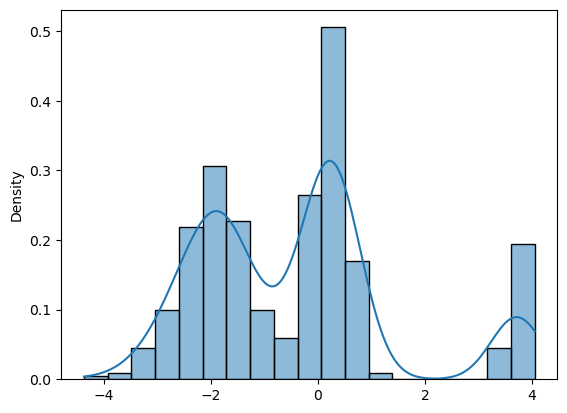

In [39]:
sns.histplot(generatedx02, stat="density", kde="True");

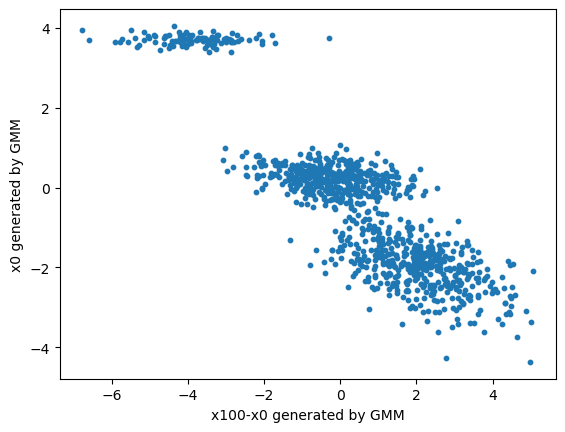

In [40]:
plt.scatter(X_gen2, generatedx02, s=10)
plt.xlabel("x100-x0 generated by GMM")
plt.ylabel("x0 generated by GMM");

### Без процесса обратной диффузии

В одномерном пространстве, поскольку данные и начальное распределение гораздо проще, чем реальные изображения, можно сгенерировать новые элементы начального распределения, просто сгенерировав GMM, подогнав все переданные модели $x_0$, и затем выбрав элементы из этой модели. В литературе указывается, что такой подход к генерации изображений нецелесообразен из-за большого количества гауссовых компонент, необходимых для моделирования таких распределений.

In [41]:
xorig=x0

In [42]:
xfor=p_forward(x_0, 99, list_bar_alphas, device).cpu().detach().numpy()

[[-3.449904   -1.1902388 ]
 [ 0.41498464 -0.14277752]
 [-0.9840925  -1.9930798 ]
 [-0.5654904   0.26632738]]


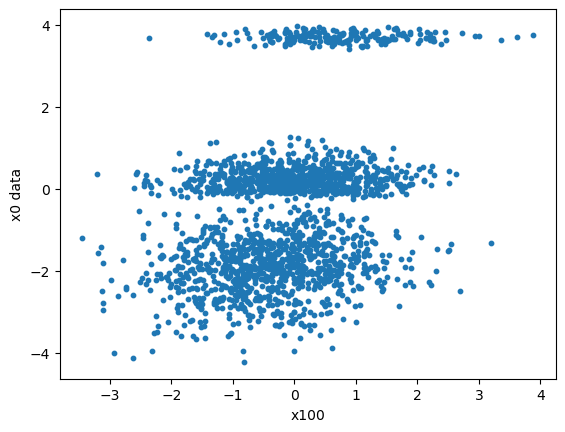

In [43]:
Xp=np.array([xfor,xorig]).T
print(Xp[:4])

plt.scatter(Xp[:,0], Xp[:,1], s=10)
plt.xlabel("x100")
plt.ylabel("x0 data");

In [44]:
GMM0 = mixture.GaussianMixture(n_components=3, covariance_type='full')
gmm0 = GMM0.fit(Xp)
data_new0 = gmm0.sample(1000)
generated0=data_new0[0]



generatedx00=[]
X_gen0=[]
for i in enumerate(generated0):
    generatedx00.append(i[1][1])
    X_gen0.append(i[1][0])



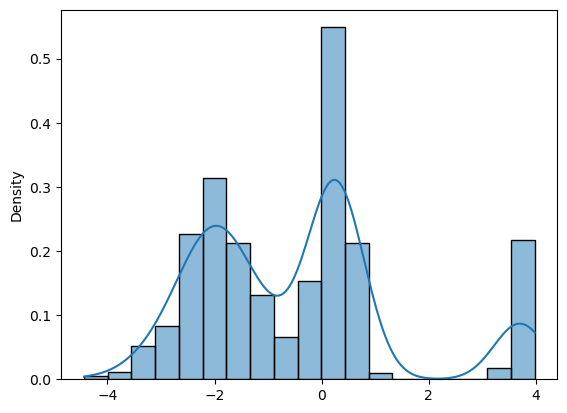

In [45]:
sns.histplot(generatedx00, stat="density", kde="True");